In [1]:
using Revise
includet("../../scripts/competing_mms.jl")

In [2]:
using JLD2

In [22]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Setup

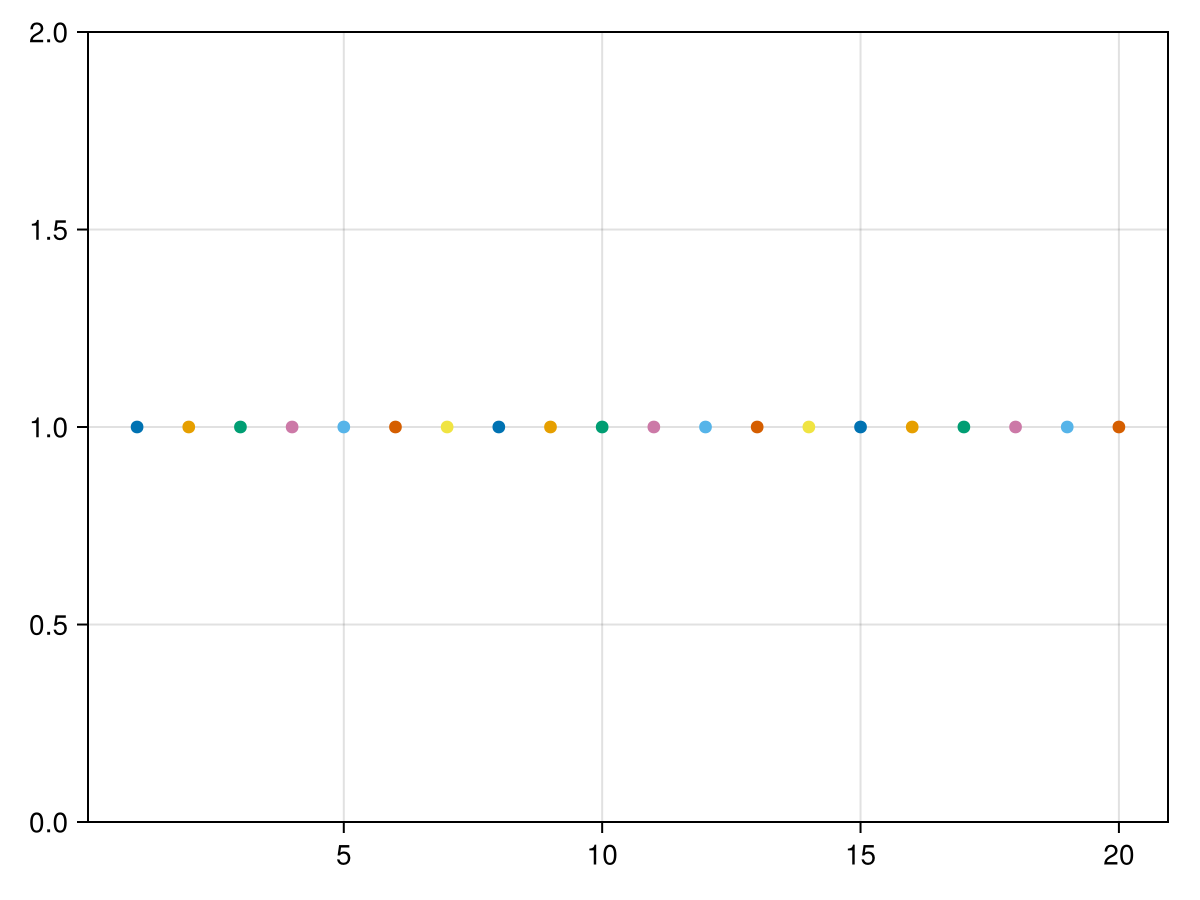

In [63]:
fig = Figure()
ax = Axis(fig[1,1])
for i in 1:20
    scatter!(ax, [i], [1]; color=Cycled(i))
end
fig

# Plotting outcomes with K

In [231]:
f = jldopen("../../cluster_env/runs/compmm_sines1/rslts2.jld2")
# f = jldopen("../../cluster_env/runs/compmm_sines1/rslts4_m_c_0.5.jld2")
md = f["params"]
Ks = f["Ks"]
results = f["results"]
num_repeats = length(f["results"][1].outcomes)
nothing

In [232]:
out_cms = map(f["results"]) do x
    countmap(x.outcomes)
end

num_ext = []
num_coex = []
num_S1 = []
num_S2 = []
for cm in out_cms
    push!(num_ext, get(cm, CMMsSpatialOutcome.Extinction, 0))
    push!(num_coex, get(cm, CMMsSpatialOutcome.Coexistence, 0))
    push!(num_S1, get(cm, CMMsSpatialOutcome.S1Only, 0))
    push!(num_S2, get(cm, CMMsSpatialOutcome.S2Only, 0))
end
@assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2) .== num_repeats)

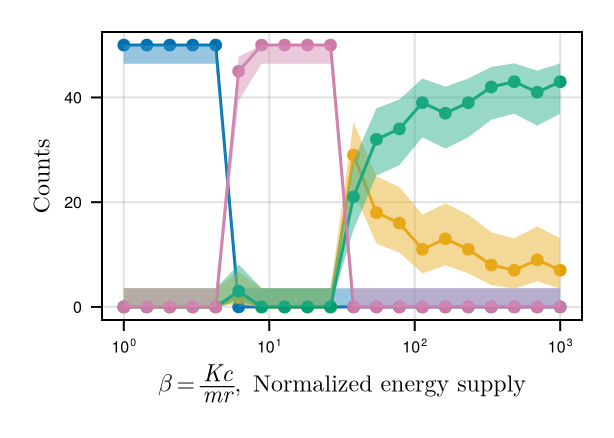

In [235]:
fig = Figure(;
    size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"\text{Counts}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

plot_binom_sample!(ax, Ks, num_ext, num_repeats)
plot_binom_sample!(ax, Ks, num_S1, num_repeats)
plot_binom_sample!(ax, Ks, num_S2, num_repeats)
plot_binom_sample!(ax, Ks, num_coex, num_repeats)

# vlines!(ax, [Ks[4], Ks[11]];
    # color=:black,
    # linestyle=:dash,
# )

Makie.save("../../figures/fig4_cmms/props.pdf", fig)

fig

# Plotting example spatial structure

In [236]:
f = jldopen("../../cluster_env/runs/compmm_sines1/rslts2.jld2")
# f = jldopen("../../cluster_env/runs/compmm_sines1/rslts4_m_c_0.5.jld2")
md = f["params"]
Ks = f["Ks"]
results = f["results"]
num_repeats = length(f["results"][1].outcomes)
nothing

In [249]:
# ii = 7
ii = 10 # for crazy final states
@show Ks[ii] countmap(results[ii].outcomes)
fs = results[ii].fss[1];

Ks[ii] = 26.366508987303583
countmap((results[ii]).outcomes) = Dict{Main.CMMsSpatialOutcome.T, Int64}(Main.CMMsSpatialOutcome.Coexistence => 50)


In [250]:
cmmps = CMMsParams(;
    K=Ks[ii],
    m1=md.m1, c1=md.c1, l1=md.l1,
    m2=md.m2, c2=md.c2, l2=md.l2,
)
Ds = [md.DN1, md.DN2, md.DI, md.DR1, md.DR2];
ps = BSMMiCRMParams(
    cmmsp_to_mmicrm(cmmps),
    Ds,
    make_cartesianspace_smart(1; dx=md.L / md.sN),
    nthreads()
);

xx = zeros(size(fs));
maximum(abs, smmicrmfunc!(xx, fs, ps))

4.5051208985569247e-8

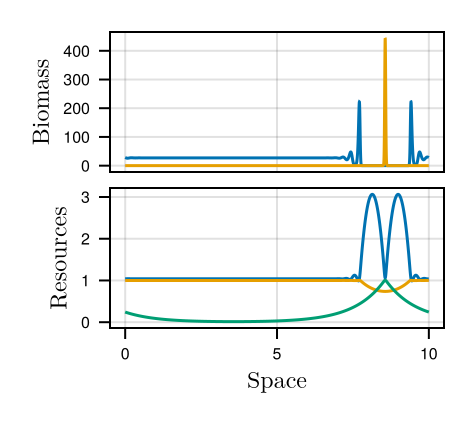

In [251]:
fig = Figure(;
    size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.5),
)
ax1 = Axis(fig[1,1];
    # xscale=log10,
    # yscale=log10
    xlabel=L"\text{Space}",
    ylabel=L"\text{Biomass}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)
ax2 = Axis(fig[2,1];
    # xscale=log10,
    # yscale=log10
    xlabel=L"\text{Space}",
    ylabel=L"\text{Resources}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)
linkxaxes!(ax1, ax2)
hidexdecorations!(ax1; grid=false)
rowgap!(fig.layout, 8.)

dx = md.L / md.sN
xs = ((1:md.sN) .- 1) .* dx;

lines!(ax1, xs, fs[1,:];
    # color=community_color,
)
lines!(ax1, xs, fs[2,:];
    # color=community_color,
)

lines!(ax2, xs, fs[3,:];
    # color=influx_resource_color,
)
lines!(ax2, xs, fs[4,:];
    # color=crossfed_resource_color,
)
lines!(ax2, xs, fs[5,:];
    # color=crossfed_resource_color,
)

# ax1.xticks = 0:5
# ax2.xticks = 0:5

# Makie.save("../../figures/fig4_cmms/fs_lowK_base.pdf", fig)

fig

In [245]:
# Test whether this is a legitimate final state
cmmps = CMMsParams(;
    K=Ks[ii],
    m1=md.m1, c1=md.c1, l1=md.l1,
    m2=md.m2, c2=md.c2, l2=md.l2,
)
Ds = [md.DN1, md.DN2, md.DI, md.DR1, md.DR2];
ps = BSMMiCRMParams(
    cmmsp_to_mmicrm(cmmps),
    Ds,
    make_cartesianspace_smart(1; dx=md.L / md.sN),
    nthreads()
);

xx = zeros(size(fs));
@sprintf "Maximum residual is %.5g" maximum(abs, smmicrmfunc!(xx, fs, ps))

"Maximum residual is 4.5051e-08"

# Adding params because I forgot before

In [7]:
close(f)
GC.gc()

In [8]:
xx = (;
    # Ks,
    m1=0.9, c1=0.9, l1=1.,
    m2=1.0, c2=1.0, l2=1.,
    DI=1., DR1=1., DR2=1.,
    DN1=1e-6, DN2=1e-6,
    numrepeats=50, T=1e8, L=10, sN=5000,
    meanN0=1., numwaves=100, waveampfactor=50.,
)

(m1 = 0.9, c1 = 0.9, l1 = 1.0, m2 = 1.0, c2 = 1.0, l2 = 1.0, DI = 1.0, DR1 = 1.0, DR2 = 1.0, DN1 = 1.0e-6, DN2 = 1.0e-6, numrepeats = 50, T = 1.0e8, L = 10, sN = 5000, meanN0 = 1.0, numwaves = 100, waveampfactor = 50.0)

In [9]:
f = jldopen("../../cluster_env/runs/compmm_sines1/rslts3.jld2", "r+")
delete!(f, "params")
f["params"] = xx
close(f)